<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Sebastián Ceballes


# Consigna
En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia f0=k0∗fS/N=k0.Δf
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea k0
 

N4
 
N4+0.25
 
N4+0.5
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

Bonus
💎 Calcule la respuesta en frecuencia de los sistemas LTI de la TS2.

# Resolución


En esta simulación analizaremos el comportamiento de la Transformada Discreta de Fourier (DFT) cuando la frecuencia de la señal analizada no coincide exactamente con los "bins" (canales) de frecuencia que resuelve el algoritmo. 

La resolución espectral está dada por $\Delta f = f_S / N$. Si la frecuencia fundamental $f_0$ de nuestra senoidal es un múltiplo entero de $\Delta f$ (es decir, $k_0$ es entero), la energía se concentra en un único bin. Evaluaremos qué sucede al introducir una pequeña desintonía fraccionaria de $0.25$ y $0.5$ bins.

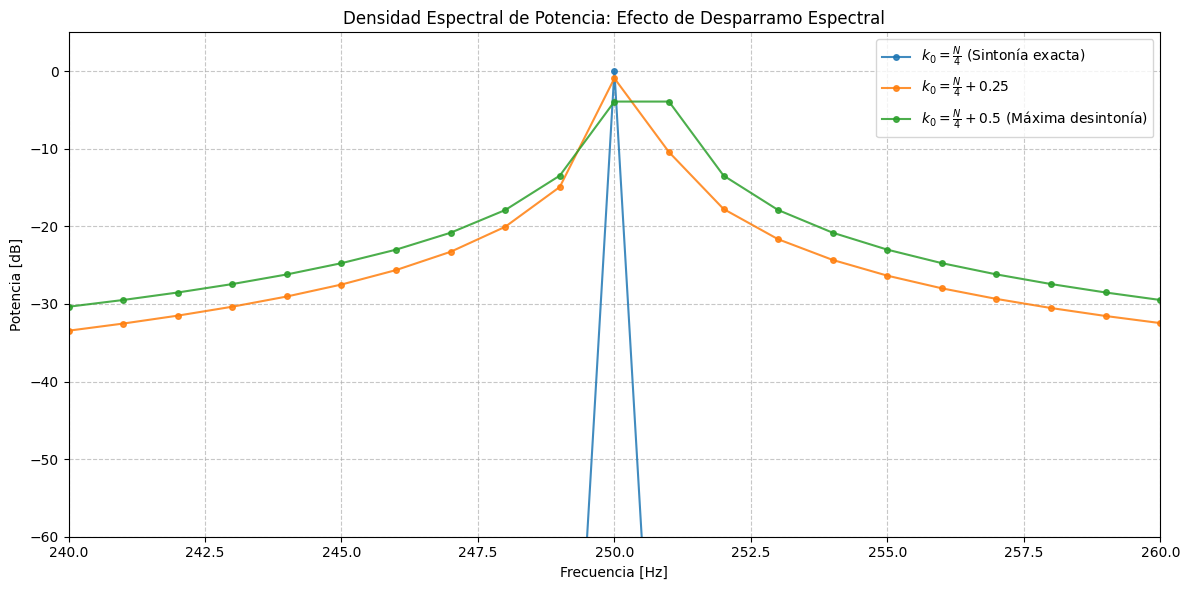

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- DEFINICION CTES ----------------------
fs = 1000 # Frecuencia muestreo (Hz)
N = 1000  # Cant. muestras
vmax = np.sqrt(2) # Amplitud para varianza unitaria (1W)
dc = 0 # Offset
ph = 0 # Fase en rad

t = np.arange(0, N/fs, 1/fs)

# Los tres casos de k_0 solicitados en la consigna
k0_valores = [N/4, N/4 + 0.25, N/4 + 0.5]
colores = ['tab:blue', 'tab:orange', 'tab:green']
etiquetas = [
    r'$k_0 = \frac{N}{4}$ (Sintonía exacta)', 
    r'$k_0 = \frac{N}{4} + 0.25$', 
    r'$k_0 = \frac{N}{4} + 0.5$ (Máxima desintonía)'
]

plt.figure(figsize=(12, 6))

# ------------------------ MAIN SCRIPT ------------------------
for k0, color, etiqueta in zip(k0_valores, colores, etiquetas):
    
    # 1. Generación de la señal para el k_0 actual
    ff = (k0 * fs) / N 
    xx = dc + vmax * np.sin(2 * np.pi * ff * t + ph)
    
    # 2. Cálculo de la DFT normalizada
    x_fft = np.fft.fft(xx) / N
    
    # 3. Densidad Espectral de Potencia (PDS) en dB
    # Se excluye la mitad redundante del espectro
    pds_db = 10 * np.log10(2 * np.abs(x_fft[:N//2])**2 + 1e-12)
    frecuencias = np.arange(N//2) * (fs/N)
    
    # 4. Graficamos superponiendo las curvas (usamos marcadores para ver los bins)
    plt.plot(frecuencias, pds_db, color=color, label=etiqueta, marker='.', ms=8, alpha=0.85)

# ------------------------ GRÁFICOS ------------------------
plt.title("Densidad Espectral de Potencia: Efecto de Desparramo Espectral")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")

# Hacemos zoom alrededor de la frecuencia central (N/4 * Delta_f = 250 Hz)
plt.xlim(240, 260)
plt.ylim([-60, 5])

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Discusión de Resultados

Al observar el gráfico centrado en 250 Hz, se evidencia claramente el efecto de la desintonía fraccionaria:

* **Sintonía exacta ($k_0 = N/4$):** La frecuencia $f_0$ (250 Hz) cae matemáticamente sobre el centro de un bin de la DFT. La energía se concentra al 100% en ese único canal (alcanzando 0 dB) y el resto del espectro cae abruptamente al piso de ruido del sistema computacional. No hay desparramo espectral.
* **Máxima desintonía ($k_0 = N/4 + 0.5$):** La frecuencia $f_0$ cae exactamente en el punto medio entre dos bins de la DFT (250 Hz y 251 Hz). Al no tener un "recipiente" exacto, el algoritmo reparte la energía de manera simétrica. El lóbulo principal se ensancha y los lóbulos laterales (*side lobes*) alcanzan su nivel máximo de interferencia, levantando artificialmente todo el piso del espectro.
* **Desintonía intermedia ($k_0 = N/4 + 0.25$):** La frecuencia está desfasada, pero más cerca de los 250 Hz. El desparramo es asimétrico; el bin de 250 Hz capta más energía que el de 251 Hz, pero de igual manera se visualiza un levantamiento generalizado del espectro (leakage) en comparación con el caso ideal.

In [2]:
# =====================================================================
# Inciso b) Verificación de la identidad de Parseval
# =====================================================================
print("--- Verificación de Potencia (Teorema de Parseval) ---")

for k0, etiqueta in zip(k0_valores, etiquetas):
    ff = (k0 * fs) / N 
    xx = dc + vmax * np.sin(2 * np.pi * ff * t + ph)
    
    # Potencia en el tiempo (Varianza o valor cuadrático medio)
    potencia_tiempo = np.mean(xx**2)
    
    # Potencia en frecuencia (Suma de los módulos al cuadrado de la DFT normalizada)
    x_fft = np.fft.fft(xx) / N
    potencia_frecuencia = np.sum(np.abs(x_fft)**2)
    
    print(f"{etiqueta}:")
    print(f"  P_tiempo = {potencia_tiempo:.4f} W  |  P_frecuencia = {potencia_frecuencia:.4f} W\n")

--- Verificación de Potencia (Teorema de Parseval) ---
$k_0 = \frac{N}{4}$ (Sintonía exacta):
  P_tiempo = 1.0000 W  |  P_frecuencia = 1.0000 W

$k_0 = \frac{N}{4} + 0.25$:
  P_tiempo = 0.9990 W  |  P_frecuencia = 0.9990 W

$k_0 = \frac{N}{4} + 0.5$ (Máxima desintonía):
  P_tiempo = 1.0000 W  |  P_frecuencia = 1.0000 W



## Discusión Teórica: Discontinuidad en la Extensión Periódica

La identidad de Parseval confirma que la energía total se conserva ($1 \text{ W}$) independientemente del desparramo. La razón por la que señales separadas por apenas fracciones de Hertz tienen espectros tan dispares radica en la suposición fundamental de la DFT: **asume que el bloque de $N$ muestras analizado se repite periódicamente hasta el infinito**.

* Cuando $f_0$ es un múltiplo exacto de $\Delta f$ (ej. $k_0 = N/4$), el bloque de $N$ muestras contiene un número entero de ciclos. Al concatenar copias del bloque, la onda resultante es una senoidal perfecta y continua.
* Cuando existe una desintonía fraccionaria, el bloque no termina donde empezó. Al asumir la repetición periódica, se genera una **discontinuidad abrupta (un salto de fase)** en los bordes de la ventana temporal.
* Matemáticamente, un salto abrupto en el dominio del tiempo requiere componentes de muy alta frecuencia para ser sintetizado. Esta energía adicional "salpica" hacia todos los demás bines de frecuencia, levantando el piso de ruido y generando el *spectral leakage*.

### Observación sobre el cálculo de potencia

Al verificar el Teorema de Parseval, se observa que la potencia para el caso fraccionario de $0.25$ es de **0.9990 W** en lugar de 1 W. Esto no es un error de cálculo ni una violación del teorema (el valor en tiempo y frecuencia coinciden). 

Este fenómeno ocurre porque el bloque de $N=1000$ muestras recorta a la senoidal en un número no entero de ciclos. Al promediar matemáticamente la señal elevada al cuadrado, el "fragmento extra" de ciclo desbalancea levemente la sumatoria, haciendo que la potencia promedio de esa ventana finita difiera infinitesimalmente de la potencia teórica de la señal continua.

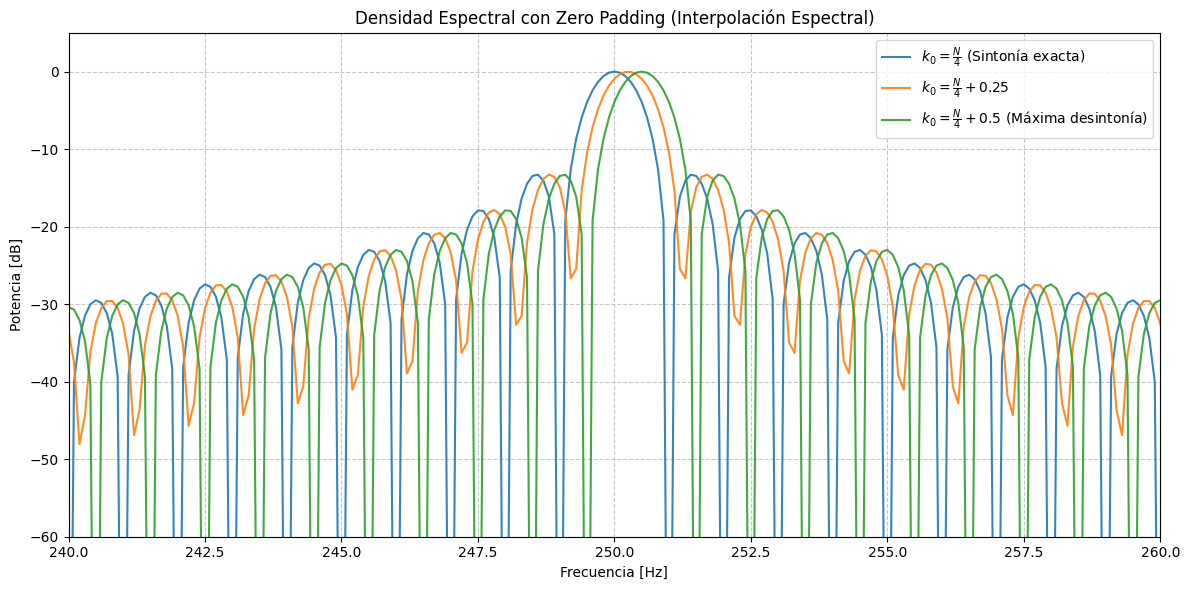

In [3]:
# =====================================================================
# Inciso c) Zero Padding (Agregando 9*N ceros)
# =====================================================================
ceros = np.zeros(9 * N)
N_pad = 10 * N

plt.figure(figsize=(12, 6))

for k0, color, etiqueta in zip(k0_valores, colores, etiquetas):
    ff = (k0 * fs) / N 
    xx = dc + vmax * np.sin(2 * np.pi * ff * t + ph)
    
    # Aplicamos Zero Padding concatenando el vector de ceros
    xx_padded = np.concatenate((xx, ceros))
    
    # Calculamos la DFT. 
    # Normalizamos por N (muestras reales de información) para mantener la escala de potencia.
    x_fft_padded = np.fft.fft(xx_padded) / N
    
    # PDS en dB
    pds_db_pad = 10 * np.log10(2 * np.abs(x_fft_padded[:N_pad//2])**2 + 1e-12)
    
    # El nuevo vector de frecuencias tiene 10 veces más puntos, reduciendo el "paso"
    frecuencias_pad = np.arange(N_pad//2) * (fs / N_pad)
    
    plt.plot(frecuencias_pad, pds_db_pad, color=color, label=etiqueta, lw=1.5, alpha=0.9)

plt.title("Densidad Espectral con Zero Padding (Interpolación Espectral)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.xlim(240, 260)
plt.ylim([-60, 5])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Discusión de Resultados: Efecto del Zero Padding

El agregado de ceros al final de la señal arroja las siguientes conclusiones visuales y analíticas:

* **Interpolación Espectral, no mayor resolución:** La técnica de zero padding disminuye el paso frecuencial en el eje horizontal (ahora tenemos puntos cada $0.1 \text{ Hz}$ en lugar de $1 \text{ Hz}$). Sin embargo, esto **no** aumenta la resolución real del sistema para distinguir dos tonos cercanos, ya que la ventana temporal efectiva ($N$ muestras originales) sigue siendo la misma. Simplemente interpola puntos intermedios.
* **Visualización de la Transformada Continua:** Al rellenar con ceros, la DFT discreta comienza a dibujar con alta definición la verdadera forma de la Transformada de Fourier de tiempo continuo de nuestra ventana finita. Se devela la clásica función **Sinc**.
* **El origen del Leakage:** Con el zero padding activo, notamos que *todas* las señales tienen lóbulos laterales (el desparramo siempre existió). En el caso de sintonía exacta ($k_0 = N/4$), los bines de la DFT original de 1000 puntos caían *exactamente* sobre los cruces por cero de la función Sinc, ocultando los lóbulos. Al desintonizar la señal, desplazamos la campana principal y obligamos a la DFT a muestrear la función Sinc fuera de sus cruces por cero, revelando la energía dispersa.

### Conclusión del Experimento con Zero Padding

Al observar el espectro de alta densidad generado por el zero padding, podemos extraer dos conclusiones fundamentales sobre el funcionamiento de la DFT:

1. **El desparramo (Leakage) siempre existió:** Las tres curvas (azul, naranja y verde) tienen exactamente la misma forma, los mismos lóbulos laterales y la misma cantidad de energía desparramada. La técnica de agregar ceros revela la verdadera forma continua del espectro (la función Sinc) que antes estaba oculta por la baja densidad de puntos.
2. **El "truco" de la sintonía exacta:** En el primer gráfico del inciso A (sin ceros), el caso azul parecía ser un "palito" perfecto de un solo armónico sin interferencia. Ahora vemos por qué: en sintonía exacta, los canales o *bins* de la DFT original de 1000 puntos caen **exactamente sobre los cruces por cero (los valles profundos)** de la función Sinc azul. Al desintonizar la señal (naranja y verde), desplazamos la campana y obligamos a la DFT a tomar muestras sobre los picos de los lóbulos laterales, "visibilizando" el desparramo que siempre estuvo allí.